In [3]:
# Load the module (if needed)
system("module load anaconda")

# Create conda environment
system("conda activate excellxgene")

In [4]:

library(reticulate)
#use_condaenv("excellxgene", required = TRUE)

# Then use the full path to the Python in that environment
use_python("/hpc/apps/anaconda/envs/excellxgene/bin/python", required = TRUE)
#use_condaenv("/hpc/apps/anaconda/envs/excellxgene:/hpc/apps/anaconda/envs/excellxgene", required = TRUE)


library(anndata)


In [5]:
py_config()


python:         /hpc/apps/anaconda/envs/excellxgene/bin/python
libpython:      /hpc/apps/anaconda/envs/excellxgene/lib/libpython3.11.so
pythonhome:     /hpc/apps/anaconda/envs/excellxgene:/hpc/apps/anaconda/envs/excellxgene
version:        3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:23:25) [GCC 13.3.0]
numpy:          /hpc/apps/anaconda/envs/excellxgene/lib/python3.11/site-packages/numpy
numpy_version:  1.26.2

NOTE: Python version was forced by use_python() function

In [6]:
adata <- read_h5ad("/hpc/projects/balla_group/sra_experiments/versioned_zf_output/75k_unstable/adata_obj/75k_unstable_anndata_zfin_aliases_metadata.h5ad")


In [7]:
# Quick summary
print(adata)  # Shows dimensions and available slots


AnnData object with n_obs × n_vars = 74275 × 49285
    obs: 'run.accession', 'study.accession', 'bioproject', 'study.title', 'sample.accession', 'experiment.accession', 'earliest_date', 'devstage_curation', 'devstage_curation_coarse', 'tissue_curation', 'tissue_curation_coarse', 'seqdetective.library_layout_curation', 'technology_curation', 'run.title', 'run.attributes', 'experiment.title', 'experiment.alias', 'experiment.library_name', 'experiment.design_description', 'experiment.library_construction_protocol', 'experiment.attributes', 'sample.description', 'sample.title', 'sample.alias', 'sample.attributes', 'submission.bioprojectsource', 'submission.bioprojectsource.country', 'GEOsample.title', 'GEOsample.dataprocessing', 'GEOsample.source', 'GEOsample.treatmentprotocol', 'GEOsample.extractprotocol', 'GEOsample.growthprotocol', 'GEOsample.characteristics', 'GEOsample.accession', 'run.filename', 'run.semantic_name', 'run.total_bases', 'run.total_spots', 'experiment.library_strategy',

In [8]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()   masks stats::filter()
✖ dplyr::lag()      masks stats::lag()
✖ readr::read_csv() masks anndata::read_csv()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [9]:
# Check metadata
adata$obs %>% head()           # Run-level metadata (your SRA runs, etc.)
names(adata$obs)               # What metadata columns you have

adata$var %>% head()           # Gene-level metadata
names(adata$var)               # Gene annotations


,run.accession,study.accession,bioproject,study.title,sample.accession,experiment.accession,earliest_date,devstage_curation,devstage_curation_coarse,tissue_curation,⋯,endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus,insufficient_evidence Cyprinid herpesvirus 1,insufficient_evidence Astyanax tetra cavefish adintovirus,insufficient_evidence Larimichthys croaker adintovirus,insufficient_evidence Cutthroat trout virus,insufficient_evidence Catfish adomavirus,insufficient_evidence Blueface angelfish adomavirus,insufficient_evidence Blotched snakehead virus,insufficient_evidence Guangdong catfish astro-like virus,insufficient_evidence Snakehead retrovirus
,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SRR1039871,SRR1039871,SRP033369,PRJNA230112,PolyA tail profiling reveals an embryonic switch in translational control,SRS508880,SRX384681,2013-11-27,Gastrula,Embryo,Embryo Imprecise,⋯,0,0,0,0,0,0,0,0,0,0
DRR162467,DRR162467,DRP004696,PRJDB7713,Age associated transcriptome analysis in 5 tissues of zebrafish,DRS083147,DRX153086,2018-12-24,Adult,Adult,Brain,⋯,0,0,0,0,0,0,0,0,0,0
SRR14915144,SRR14915144,SRP324000,PRJNA737474,Construction the larval and adult zebrafish cell atlas at single cell resolution,SRS9283331,SRX11229436,2021-06-25,Adult,Adult,Whole Organism,⋯,0,0,0,0,0,0,0,0,0,0
SRR11114789,SRR11114789,SRP250035,PRJNA607563,Transcriptomic profile of zebrafish liver cells in thioacetamide TAA model,SRS6171083,SRX7751792,2020-02-19,Larval,Larval,Liver,⋯,0,0,0,0,0,0,0,0,0,0
ERR1888374,ERR1888374,ERP022169,PRJEB20058,Single cell RNA Seq data of zebrafish blood cells,ERS1611138,ERX1948872,2017-03-20,Adult,Adult,Multi-tissue,⋯,0,0,0,0,0,0,0,0,0,0
ERR667426,ERR667426,ERP008536,PRJEB7614,Screening zebrafish embryos treated with small molecules by transcriptome profiling,ERS463367,ERX622914,2014-11-04,Pharyngula,Embryo,Embryo Imprecise,⋯,0,0,0,0,0,0,0,0,0,0


[1] "run.accession"                                                      
  [2] "study.accession"                                                    
  [3] "bioproject"                                                         
  [4] "study.title"                                                        
  [5] "sample.accession"                                                   
  [6] "experiment.accession"                                               
  [7] "earliest_date"                                                      
  [8] "devstage_curation"                                                  
  [9] "devstage_curation_coarse"                                           
 [10] "tissue_curation"                                                    
 [11] "tissue_curation_coarse"                                             
 [12] "seqdetective.library_layout_curation"                               
 [13] "technology_curation"                                                
 [14] "run.title"                                                          
 [15] "run.attributes"                                                     
 [16] "experiment.title"                                                   
 [17] "experiment.alias"                                                   
 [18] "experiment.library_name"                                            
 [19] "experiment.design_description"                                      
 [20] "experiment.library_construction_protocol"                           
 [21] "experiment.attributes"                                              
 [22] "sample.description"                                                 
 [23] "sample.title"                                                       
 [24] "sample.alias"                                                       
 [25] "sample.attributes"                                                  
 [26] "submission.bioprojectsource"                                        
 [27] "submission.bioprojectsource.country"                                
 [28] "GEOsample.title"                                                    
 [29] "GEOsample.dataprocessing"                                           
 [30] "GEOsample.source"                                                   
 [31] "GEOsample.treatmentprotocol"                                        
 [32] "GEOsample.extractprotocol"                                          
 [33] "GEOsample.growthprotocol"                                           
 [34] "GEOsample.characteristics"                                          
 [35] "GEOsample.accession"                                                
 [36] "run.filename"                                                       
 [37] "run.semantic_name"                                                  
 [38] "run.total_bases"                                                    
 [39] "run.total_spots"                                                    
 [40] "experiment.library_strategy"                                        
 [41] "experiment.library_source"                                          
 [42] "experiment.library_selection"                                       
 [43] "experiment.library_layout"                                          
 [44] "experiment.platform"                                                
 [45] "experiment.instrument_model"                                        
 [46] "experiment.spot_descriptor"                                         
 [47] "study.alias"                                                        
 [48] "study.type"                                                         
 [49] "study.abstract"                                                     
 [50] "study.attributes"                                                   
 [51] "study.PMIDs"                                                        
 [52] "run.alias"                                                          
 [53] "run.read_lengths"                          

,gene_id,ZFIN,ncbi_id,miRBase,ncbi_id_z12_to_z11,ZFIN_key,gene_symbol_zfin_aliases,gene_biotype,gene_length,gene_ens_id
,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>
LOC141383674,LOC141383674,NA,GeneID:141383674,NA,GeneID:141383674,NA,LOC141383674,NA,NaN,NA
rpl24,rpl24,ZDB-GENE-020419-25,GeneID:192301,NA,GeneID:192301,020419-25,rpl24,protein_coding,5620,ENSDARG00000099104
cep97,cep97,ZDB-GENE-031030-11,GeneID:386640,NA,GeneID:386640,031030-11,cep97,protein_coding,4552,ENSDARG00000102407
nfkbiz,nfkbiz,ZDB-GENE-071024-1,GeneID:100001781,NA,GeneID:100001781,071024-1,nfkbiz,protein_coding,4674,ENSDARG00000102097
eed,eed,ZDB-GENE-050417-287,GeneID:550463,NA,GeneID:550463,050417-287,eed,protein_coding,6641,ENSDARG00000099640
hikeshi,hikeshi,ZDB-GENE-050417-34,GeneID:550239,NA,GeneID:550239,050417-34,hikeshi,protein_coding,2640,ENSDARG00000104071


[1] "gene_id"                  "ZFIN"                    
 [3] "ncbi_id"                  "miRBase"                 
 [5] "ncbi_id_z12_to_z11"       "ZFIN_key"                
 [7] "gene_symbol_zfin_aliases" "gene_biotype"            
 [9] "gene_length"              "gene_ens_id"

In [10]:
# The actual run IDs (row names)
head(adata$obs_names)  # Should be your SRR... accessions
tail(adata$obs_names)  # Should be your SRR... accessions

# The actual feature names (column names) - genes + viruses
head(adata$var_names)  # Gene IDs
tail(adata$var_names)  # Probably viruses at the end?


# The run metadata (74,275 rows × many columns)
adata$obs %>% glimpse()

# Check specific metadata column
adata$obs$tissue_curation %>% table()


[1] "SRR1039871"  "DRR162467"   "SRR14915144" "SRR11114789" "ERR1888374" 
[6] "ERR667426"

[1] "ERR1374455"  "ERR1407563"  "SRR15600914" "SRR26533144" "SRR27346120"
[6] "SRR14993668"

[1] "LOC141383674" "rpl24"        "cep97"        "nfkbiz"       "eed"         
[6] "hikeshi"

[1] "ND5"  "ND6"  "trnE" "CYTB" "trnT" "trnP"

Rows: 74,275
Columns: 122
$ run.accession                                                         <chr> …
$ study.accession                                                       <fct> …
$ bioproject                                                            <fct> …
$ study.title                                                           <fct> …
$ sample.accession                                                      <fct> …
$ experiment.accession                                                  <fct> …
$ earliest_date                                                         <fct> …
$ devstage_curation                                                     <fct> …
$ devstage_curation_coarse                                              <fct> …
$ tissue_curation                                                       <fct> …
$ tissue_curation_coarse                                                <fct> …
$ seqdetective.library_layout_curation                                  <fct> …
$ technology_c

.
    Adipose Tissue BCR TCR repertoire              Blood  Bone or Cartilage 
                57                 65                569                119 
             Brain    Cancer or Tumor          Cell Line                Ear 
              6012               1115                383                 18 
  Embryo Imprecise        Endothelium                Eye                Fin 
              8543                361               1505               1236 
              Gill              Gonad                Gut               Head 
               259               1008                708                704 
             Heart                Jaw             Kidney       Lateral Line 
              2861                 84               1008                200 
             Liver   Lymphatic System             Marrow       Multi-tissue 
              1806                 63                 49               5082 
            Muscle             Oocyte           Pancreas    Pharyngeal Arc

In [11]:
# Get all virus data with key metadata
virus_data <- adata$obs %>%
  select(run.accession, tissue_curation, tissue_curation_coarse, 
         devstage_curation, devstage_curation_coarse,
         contains("virus"), contains("Novel"), 
         starts_with("endogenous"), starts_with("insufficient"))



In [12]:
virus_data

,run.accession,tissue_curation,tissue_curation_coarse,devstage_curation,devstage_curation_coarse,Zebrafish jaw poxvirus,Danio blood picornavirus_Zebrafish picornavirus 2,Influenza Z virus,Zebrafish jaw picornavirus,Zebrafish hepatic paramyxovirus,⋯,endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus,insufficient_evidence Cyprinid herpesvirus 1,insufficient_evidence Astyanax tetra cavefish adintovirus,insufficient_evidence Larimichthys croaker adintovirus,insufficient_evidence Cutthroat trout virus,insufficient_evidence Catfish adomavirus,insufficient_evidence Blueface angelfish adomavirus,insufficient_evidence Blotched snakehead virus,insufficient_evidence Guangdong catfish astro-like virus,insufficient_evidence Snakehead retrovirus
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SRR1039871,SRR1039871,Embryo Imprecise,All anatomical structures,Gastrula,Embryo,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DRR162467,DRR162467,Brain,Nervous System,Adult,Adult,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR14915144,SRR14915144,Whole Organism,All anatomical structures,Adult,Adult,192,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR11114789,SRR11114789,Liver,Liver and Biliary System,Larval,Larval,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR1888374,ERR1888374,Multi-tissue,Multi-system,Adult,Adult,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR667426,ERR667426,Embryo Imprecise,All anatomical structures,Pharyngula,Embryo,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR1374464,ERR1374464,Undetermined,Undetermined,Undetermined,Undetermined,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR25509987,SRR25509987,Tail,Multi-system,Larval,Larval,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR28358951,SRR28358951,Pancreas,Endocrine System,Undetermined,Larval,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [13]:
# Which viruses are most prevalent?
virus_data %>%
  select(contains("virus") | contains("Novel")) %>%
  summarise(across(everything(), ~sum(. > 0, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "virus", values_to = "n_positive_runs") %>%
  arrange(desc(n_positive_runs))

virus_positive_runcount <- virus_data %>%
  select(contains("virus") | contains("Novel")) %>%
  summarise(across(everything(), ~sum(. > 0, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "virus", values_to = "n_positive_runs") %>%
  arrange(desc(n_positive_runs))
virus_positive_runcount %>% print(n = 53)


virus,n_positive_runs
<chr>,<int>
endogenous_or_nonfish Pimephales minnow adintovirus,16427
endogenous_or_nonfish Chuvivirus,4245
Zebrafish jaw poxvirus,2984
Danio blood picornavirus_Zebrafish picornavirus 2,2612
Zebrafish picornavirus 1,2483
endogenous_or_nonfish Sea turtle neural virus 1,2252
insufficient_evidence Cyprinid herpesvirus 1,2159
endogenous_or_nonfish African cichlid piscichuvirus,1497
endogenous_or_nonfish Salarius guttatus piscichuvirus,1291


# A tibble: 53 × 2
   virus                                                         n_positive_runs
   <chr>                                                                   <int>
 1 endogenous_or_nonfish Pimephales minnow adintovirus                     16427
 2 endogenous_or_nonfish Chuvivirus                                         4245
 3 Zebrafish jaw poxvirus                                                   2984
 4 Danio blood picornavirus_Zebrafish picornavirus 2                        2612
 5 Zebrafish picornavirus 1                                                 2483
 6 endogenous_or_nonfish Sea turtle neural virus 1                          2252
 7 insufficient_evidence Cyprinid herpesvirus 1                             2159
 8 endogenous_or_nonfish African cichlid piscichuvirus                      1497
 9 endogenous_or_nonfish Salarius guttatus piscichuvirus                    1291
10 Zebrafish jaw picornavirus                                                468
11 endoge

In [14]:
virus_positive_runcount %>% print(n = 53)

# A tibble: 53 × 2
   virus                                                         n_positive_runs
   <chr>                                                                   <int>
 1 endogenous_or_nonfish Pimephales minnow adintovirus                     16427
 2 endogenous_or_nonfish Chuvivirus                                         4245
 3 Zebrafish jaw poxvirus                                                   2984
 4 Danio blood picornavirus_Zebrafish picornavirus 2                        2612
 5 Zebrafish picornavirus 1                                                 2483
 6 endogenous_or_nonfish Sea turtle neural virus 1                          2252
 7 insufficient_evidence Cyprinid herpesvirus 1                             2159
 8 endogenous_or_nonfish African cichlid piscichuvirus                      1497
 9 endogenous_or_nonfish Salarius guttatus piscichuvirus                    1291
10 Zebrafish jaw picornavirus                                                468
11 endoge

In [15]:
# First, identify ALL virus columns properly
virus_cols <- grep("virus|Novel|endogenous|insufficient|Cyprinid|Grass carp|Salmon|bass virus|grouper|Sprivivirus|Wenzhou|Zebrafish picornavirus|Rocky Mountain|ricketti", 
                   names(adata$obs), value = TRUE, ignore.case = TRUE)

# Check what you got
length(virus_cols)
head(virus_cols)

[1] 53

[1] "Zebrafish jaw poxvirus"                           
[2] "Danio blood picornavirus_Zebrafish picornavirus 2"
[3] "Influenza Z virus"                                
[4] "Zebrafish jaw picornavirus"                       
[5] "Zebrafish hepatic paramyxovirus"                  
[6] "Zebrafish gut calicivirus"

In [16]:


# Now use those specific columns
# Virus counts by tissue (handling NAs)
virus_data %>%
  group_by(tissue_curation_coarse) %>%
  summarise(across(all_of(virus_cols), ~sum(., na.rm = TRUE))) %>%
  pivot_longer(-tissue_curation_coarse, names_to = "virus", values_to = "total_counts") %>%
  filter(total_counts > 0) %>%  # Remove zeros to see what actually has data
  arrange(desc(total_counts))


tissue_curation_coarse,virus,total_counts
<fct>,<chr>,<dbl>
Surface Structure,Spring viraemia of carp virus,30440547
Undetermined,Spring viraemia of carp virus,5498134
Respiratory System,Spring viraemia of carp virus,2078104
Surface Structure,Zebrafish jaw poxvirus,1623901
Hematopoietic System,Spring viraemia of carp virus,662149
Hematopoietic System,Zebrafish jaw poxvirus,503354
Respiratory System,Zebrafish jaw poxvirus,261984
Cancer or Tumor,Danio blood picornavirus_Zebrafish picornavirus 2,203343
Renal System,Spring viraemia of carp virus,195361


In [17]:
virus_data

,run.accession,tissue_curation,tissue_curation_coarse,devstage_curation,devstage_curation_coarse,Zebrafish jaw poxvirus,Danio blood picornavirus_Zebrafish picornavirus 2,Influenza Z virus,Zebrafish jaw picornavirus,Zebrafish hepatic paramyxovirus,⋯,endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus,insufficient_evidence Cyprinid herpesvirus 1,insufficient_evidence Astyanax tetra cavefish adintovirus,insufficient_evidence Larimichthys croaker adintovirus,insufficient_evidence Cutthroat trout virus,insufficient_evidence Catfish adomavirus,insufficient_evidence Blueface angelfish adomavirus,insufficient_evidence Blotched snakehead virus,insufficient_evidence Guangdong catfish astro-like virus,insufficient_evidence Snakehead retrovirus
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SRR1039871,SRR1039871,Embryo Imprecise,All anatomical structures,Gastrula,Embryo,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DRR162467,DRR162467,Brain,Nervous System,Adult,Adult,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR14915144,SRR14915144,Whole Organism,All anatomical structures,Adult,Adult,192,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR11114789,SRR11114789,Liver,Liver and Biliary System,Larval,Larval,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR1888374,ERR1888374,Multi-tissue,Multi-system,Adult,Adult,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR667426,ERR667426,Embryo Imprecise,All anatomical structures,Pharyngula,Embryo,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR1374464,ERR1374464,Undetermined,Undetermined,Undetermined,Undetermined,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR25509987,SRR25509987,Tail,Multi-system,Larval,Larval,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR28358951,SRR28358951,Pancreas,Endocrine System,Undetermined,Larval,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [18]:
## a larger set of virus_data with date & country...

# Get all virus data with key metadata
virus_datamore <- adata$obs %>%
  select(run.accession, tissue_curation, tissue_curation_coarse, 
         devstage_curation, devstage_curation_coarse, earliest_date, submission.bioprojectsource.country,
         contains("virus"), contains("Novel"), 
         starts_with("endogenous"), starts_with("insufficient"))


head(virus_datamore)

,run.accession,tissue_curation,tissue_curation_coarse,devstage_curation,devstage_curation_coarse,earliest_date,submission.bioprojectsource.country,Zebrafish jaw poxvirus,Danio blood picornavirus_Zebrafish picornavirus 2,Influenza Z virus,⋯,endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus,insufficient_evidence Cyprinid herpesvirus 1,insufficient_evidence Astyanax tetra cavefish adintovirus,insufficient_evidence Larimichthys croaker adintovirus,insufficient_evidence Cutthroat trout virus,insufficient_evidence Catfish adomavirus,insufficient_evidence Blueface angelfish adomavirus,insufficient_evidence Blotched snakehead virus,insufficient_evidence Guangdong catfish astro-like virus,insufficient_evidence Snakehead retrovirus
,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SRR1039871,SRR1039871,Embryo Imprecise,All anatomical structures,Gastrula,Embryo,2013-11-27,United States,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DRR162467,DRR162467,Brain,Nervous System,Adult,Adult,2018-12-24,Japan,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR14915144,SRR14915144,Whole Organism,All anatomical structures,Adult,Adult,2021-06-25,China,192,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR11114789,SRR11114789,Liver,Liver and Biliary System,Larval,Larval,2020-02-19,Poland,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR1888374,ERR1888374,Multi-tissue,Multi-system,Adult,Adult,2017-03-20,United Kingdom,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ERR667426,ERR667426,Embryo Imprecise,All anatomical structures,Pharyngula,Embryo,2014-11-04,United Kingdom,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [19]:
## save .tsv
virus_datamorereordered <- adata$obs %>%
  select(run.accession,
         contains("virus"), contains("Novel"), 
         starts_with("endogenous"), starts_with("insufficient"), tissue_curation, tissue_curation_coarse, 
         devstage_curation, devstage_curation_coarse, earliest_date, submission.bioprojectsource.country)


# Verify rownames match run.accession column before removing
all(rownames(virus_datamorereordered) == virus_datamorereordered$run.accession)  # should be TRUE

# Then reset
rownames(virus_datamorereordered) <- NULL



[1] TRUE

In [22]:
## fyi there are 74275 rows but 350 that are NAs - leaving 73925 instead of 73955?

#df_subset <- read_tsv("all.quantt_sept24_fishassociated_mar26update.tsv.gz")
#head(df_subset)
# Rows: 73955 Columns: 8651

## in notebook B (aka reducing_virusmatrix_code_mar26_latest) it starts with 73955...

## by end it saves as write_tsv(df_with_metadata, "all.quantt_sept24_fishassociated_mar26clusters_withallmetadata.tsv")

## WE ALREADY HAVE THIS FROM END OF B
#write_tsv(df_with_metadata_less, "all.quantt_sept24_fishassociated_mar26clusters_withselectmetadata.tsv")

## save
#virus_datamorereordered
#write.table(virus_datamorereordered, file = paste0("curated_virus_viralcounts_withmetadata.tsv"), sep = "\t", row.names = FALSE, quote = FALSE)

## reload all.quantt_sept24_fishassociated_mar26clusters_withselectmetadata.tsv

virus_datamorereordered2 <- read_tsv("all.quantt_sept24_fishassociated_mar26clusters_withselectmetadata.tsv")


colnames(virus_datamorereordered2)


Rows: 73955 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (9): bioproject, run_name, devstage_curation, devstage_curation_coarse...
dbl  (53): Zebrafish jaw poxvirus, Danio blood picornavirus/Zebrafish picorn...
date  (1): earliest_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "bioproject"                                                         
 [2] "run_name"                                                           
 [3] "Zebrafish jaw poxvirus"                                             
 [4] "Danio blood picornavirus/Zebrafish picornavirus 2"                  
 [5] "Influenza Z virus"                                                  
 [6] "Zebrafish jaw picornavirus"                                         
 [7] "Zebrafish hepatic paramyxovirus"                                    
 [8] "Zebrafish gut calicivirus"                                          
 [9] "Zebrafish rhabdo-like virus"                                        
[10] "Zebrafish arterivirus"                                              
[11] "Zebrafish neurinoma calicivirus"                                    
[12] "Zebrafish neural hantavirus"                                        
[13] "Zebrafish systemic paramyxovirus"                                   
[14] "Zebrafish influenza-like virus"                                     
[15] "Zebrafish adomavirus"                                               
[16] "Zebrafish cardiovascular hantavirus"                                
[17] "Zebrafish systemic calicivirus"                                     
[18] "Zebrafish gonadal hantavirus"                                       
[19] "Spring viraemia of carp virus"                                      
[20] "Cyprinid herpesvirus 3"                                             
[21] "Zebrafish picornavirus 1"                                           
[22] "Redspotted grouper nervous necrosis virus"                          
[23] "Rocky Mountain birnavirus"                                          
[24] "Largemouth bass virus"                                              
[25] "Infectious Salmon Anemia Virus"                                     
[26] "Myotis ricketti associated fish calicivirus"                        
[27] "Wenzhou shark flavivirus"                                           
[28] "Grass carp reovirus"                                                
[29] "Singapore grouper virus"                                            
[30] "endogenous_or_nonfish Pimephales minnow adintovirus"                
[31] "endogenous_or_nonfish Chuvivirus"                                   
[32] "endogenous_or_nonfish Sea turtle neural virus 1"                    
[33] "endogenous_or_nonfish Psittacidae aveparvovirus"                    
[34] "endogenous_or_nonfish Adintovirus anguilla10665"                    
[35] "endogenous_or_nonfish African cichlid piscichuvirus"                
[36] "endogenous_or_nonfish Salarius guttatus piscichuvirus"              
[37] "endogenous_or_nonfish Deltainfluenzavirus"                          
[38] "endogenous_or_nonfish Fish-associated parvo-like hybrid virus"      
[39] "endogenous_or_nonfish Fish-associated picorna-like virus 3"         
[40] "endogenous_or_nonfish Psittaciform aveparvovirus"                   
[41] "endogenous_or_nonfish Flumine Astrovirus 3"                         
[42] "endogenous_or_nonfish Luscinia sibilans parvo-like hybrid virus"    
[43] "endogenous_or_nonfish Hardyhead chuvirus"                           
[44] "endogenous_or_nonfish Leatherback sea turtle adomavirus"            
[45] "endogenous_or_nonfish Phoenicopteridae parvo-like hybrid virus"     
[46] "endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus"
[47] "insufficient_evidence Cyprinid herpesvirus 1"                       
[48] "insufficient_evidence Astyanax tetra cavefish adintovirus"          
[49] "insufficient_evidence Larimichthys croaker adintovirus"             
[50] "insufficient_evidence Cutthroat trout virus"                        
[51] "insufficient_evidence Catfish adomavirus"                           
[52] "insufficient_evidence Blueface angelfish adomavirus"                
[53] "insufficient_evidence Blotched snakehead virus"                     
[54] "insufficient_evidenc

In [23]:
virus_datamorereordered2 <- virus_datamorereordered2 %>%
  select(run_name, bioproject,
         contains("virus"), contains("Novel"), 
         starts_with("endogenous"), starts_with("insufficient"), technology_curation, seqdetective.library_layout_curation, tissue_curation, tissue_curation_coarse, 
         devstage_curation, devstage_curation_coarse, earliest_date, submission.bioprojectsource.country)

virus_datamorereordered2 <- virus_datamorereordered2 %>% rename(run.accession = run_name)

## reorder two technology columns then save as
## curated_virus_viralcounts_withmetadata
write.table(virus_datamorereordered2, file = paste0("curated_virus_viralcounts_withmetadata.tsv"), sep = "\t", row.names = FALSE, quote = FALSE)

virus_datamorereordered2

run.accession,bioproject,Zebrafish jaw poxvirus,Danio blood picornavirus/Zebrafish picornavirus 2,Influenza Z virus,Zebrafish jaw picornavirus,Zebrafish hepatic paramyxovirus,Zebrafish gut calicivirus,Zebrafish rhabdo-like virus,Zebrafish arterivirus,⋯,insufficient_evidence Guangdong catfish astro-like virus,insufficient_evidence Snakehead retrovirus,technology_curation,seqdetective.library_layout_curation,tissue_curation,tissue_curation_coarse,devstage_curation,devstage_curation_coarse,earliest_date,submission.bioprojectsource.country
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<chr>
DRR029935,PRJDB3475,0,7,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029936,PRJDB3475,0,1,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029937,PRJDB3475,0,0,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029938,PRJDB3475,0,1,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029939,PRJDB3475,0,4,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029940,PRJDB3475,0,4,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029941,PRJDB3475,0,7,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029942,PRJDB3475,0,0,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Gonad,Reproductive System,Adult,Adult,2019-01-23,Japan
DRR029943,PRJDB3475,0,2,0,0,0,0,0,0,⋯,0,0,unknown,SINGLE,Multi-tissue,Multi-system,Adult,Adult,2019-01-23,Japan


In [21]:
## now some plots


In [23]:
virus_by_tissue <- virus_data %>%
  group_by(tissue_curation_coarse) %>%
  summarise(across(all_of(virus_cols), ~sum(., na.rm = TRUE))) %>%
  pivot_longer(-tissue_curation_coarse, names_to = "virus", values_to = "total_counts") %>%
  filter(total_counts > 0)



In [24]:
head(virus_by_tissue)

tissue_curation_coarse,virus,total_counts
<fct>,<chr>,<dbl>
Adipose Tissue,Zebrafish jaw poxvirus,13
Adipose Tissue,Danio blood picornavirus_Zebrafish picornavirus 2,573
Adipose Tissue,Zebrafish jaw picornavirus,21
Adipose Tissue,Zebrafish picornavirus 1,221
Adipose Tissue,endogenous_or_nonfish Pimephales minnow adintovirus,630
Adipose Tissue,endogenous_or_nonfish Chuvivirus,7


In [25]:
### LET'S CREATE A VIRUS ORDER BY CATEGORY + TOTAL COUNTS AND WE CAN USE THIS THROUGHOUT ALL PLOTS...

## first let's add cheatsheet with Category...
## to both virus_by_tissue
viruses_withcategory0 <- read_tsv(
  "novel_viruses_names_cheatsheet.tsv",
  show_col_types = FALSE
)
cat("  Raw rows:", nrow(viruses_withcategory0), "\n")

viruses_withcategory <- viruses_withcategory0 %>% group_by(clusterLCA_curated) %>% slice_head(n = 1) %>% select(clusterLCA_curated,Category)
viruses_withcategory <- viruses_withcategory %>% rename(virus = clusterLCA_curated)
viruses_withcategory <- viruses_withcategory %>% mutate(virus = str_replace_all(virus, c("Danio blood picornavirus/Zebrafish picornavirus 2" = "Danio blood picornavirus_Zebrafish picornavirus 2")))

#head(viruses_withcategory)
## now repeat for clusterLCA_curated0 & combine into one larger list

viruses_withcategory2 <- viruses_withcategory0 %>% group_by(clusterLCA_curated0) %>% slice_head(n = 1) %>% select(clusterLCA_curated0,Category)

#head(viruses_withcategory2)
viruses_withcategory2 <- viruses_withcategory2 %>% rename(virus = clusterLCA_curated0)

## now bind_rows

viruses_withcategory12 <- bind_rows(viruses_withcategory,viruses_withcategory2)

head(viruses_withcategory12)

  Raw rows: 160 


virus,Category
<chr>,<chr>
Adintovirus anguilla10665,Endogenous or not fish-associated
African cichlid piscichuvirus,Endogenous or not fish-associated
Astyanax tetra cavefish adintovirus,Insufficient Evidence
Blotched snakehead virus,Insufficient Evidence
Blueface angelfish adomavirus,Insufficient Evidence
Catfish adomavirus,Insufficient Evidence


In [26]:
# Join
cat("\n  Matching to curated virus list (primary only)...\n")

virus_by_tissue0 <- virus_by_tissue
virus_by_tissue <- left_join(virus_by_tissue0,viruses_withcategory12)

virus_by_tissue



  Matching to curated virus list (primary only)...


Joining with `by = join_by(virus)`


tissue_curation_coarse,virus,total_counts,Category
<fct>,<chr>,<dbl>,<chr>
Adipose Tissue,Zebrafish jaw poxvirus,13,Novel
Adipose Tissue,Danio blood picornavirus_Zebrafish picornavirus 2,573,Novel
Adipose Tissue,Zebrafish jaw picornavirus,21,Novel
Adipose Tissue,Zebrafish picornavirus 1,221,Known
Adipose Tissue,endogenous_or_nonfish Pimephales minnow adintovirus,630,Endogenous or not fish-associated
Adipose Tissue,endogenous_or_nonfish Chuvivirus,7,Endogenous or not fish-associated
Adipose Tissue,endogenous_or_nonfish Sea turtle neural virus 1,7,Endogenous or not fish-associated
Adipose Tissue,endogenous_or_nonfish African cichlid piscichuvirus,11,Endogenous or not fish-associated
Adipose Tissue,insufficient_evidence Cyprinid herpesvirus 1,4,Insufficient Evidence


In [27]:
sum(virus_by_tissue$total_counts)

[1] 42926972

In [28]:
## this will result in virus_order that can be used for all downstream plots...
category_order <- c("Novel", "Known", 
                    "Endogenous or not fish-associated", "Insufficient Evidence")


virus_by_tissue2 <- virus_by_tissue %>%
  mutate(Category = factor(Category, levels = category_order))



virus_order <- virus_by_tissue2 %>% ungroup()  %>% 
#  filter(virus %in% virus_3subset) %>%
  group_by(Category,virus) %>%
  summarise(virus_total = sum(total_counts, na.rm = TRUE)) %>%
  arrange(Category, desc(virus_total)) %>%
  pull(virus)


virus_order
virus_order[1]



`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


[1] "Zebrafish jaw poxvirus"                                             
 [2] "Danio blood picornavirus_Zebrafish picornavirus 2"                  
 [3] "Influenza Z virus"                                                  
 [4] "Zebrafish jaw picornavirus"                                         
 [5] "Zebrafish hepatic paramyxovirus"                                    
 [6] "Zebrafish gut calicivirus"                                          
 [7] "Zebrafish rhabdo-like virus"                                        
 [8] "Zebrafish arterivirus"                                              
 [9] "Zebrafish neurinoma calicivirus"                                    
[10] "Zebrafish neural hantavirus"                                        
[11] "Zebrafish systemic paramyxovirus"                                   
[12] "Zebrafish influenza-like virus"                                     
[13] "Zebrafish adomavirus"                                               
[14] "Zebrafish cardiovascular hantavirus"                                
[15] "Zebrafish systemic calicivirus"                                     
[16] "Zebrafish gonadal hantavirus"                                       
[17] "Spring viraemia of carp virus"                                      
[18] "Cyprinid herpesvirus 3"                                             
[19] "Zebrafish picornavirus 1"                                           
[20] "Redspotted grouper nervous necrosis virus"                          
[21] "Rocky Mountain birnavirus"                                          
[22] "Largemouth bass virus"                                              
[23] "Infectious Salmon Anemia Virus"                                     
[24] "Myotis ricketti associated fish calicivirus"                        
[25] "Wenzhou shark flavivirus"                                           
[26] "Grass carp reovirus"                                                
[27] "Singapore grouper virus"                                            
[28] "endogenous_or_nonfish Pimephales minnow adintovirus"                
[29] "endogenous_or_nonfish Chuvivirus"                                   
[30] "endogenous_or_nonfish Sea turtle neural virus 1"                    
[31] "endogenous_or_nonfish Psittacidae aveparvovirus"                    
[32] "endogenous_or_nonfish Adintovirus anguilla10665"                    
[33] "endogenous_or_nonfish African cichlid piscichuvirus"                
[34] "endogenous_or_nonfish Salarius guttatus piscichuvirus"              
[35] "endogenous_or_nonfish Deltainfluenzavirus"                          
[36] "endogenous_or_nonfish Fish-associated parvo-like hybrid virus"      
[37] "endogenous_or_nonfish Fish-associated picorna-like virus 3"         
[38] "endogenous_or_nonfish Psittaciform aveparvovirus"                   
[39] "endogenous_or_nonfish Flumine Astrovirus 3"                         
[40] "endogenous_or_nonfish Luscinia sibilans parvo-like hybrid virus"    
[41] "endogenous_or_nonfish Hardyhead chuvirus"                           
[42] "endogenous_or_nonfish Leatherback sea turtle adomavirus"            
[43] "endogenous_or_nonfish Phoenicopteridae parvo-like hybrid virus"     
[44] "endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus"
[45] "insufficient_evidence Cyprinid herpesvirus 1"                       
[46] "insufficient_evidence Astyanax tetra cavefish adintovirus"          
[47] "insufficient_evidence Larimichthys croaker adintovirus"             
[48] "insufficient_evidence Cutthroat trout virus"                        
[49] "insufficient_evidence Catfish adomavirus"                           
[50] "insufficient_evidence Blueface angelfish adomavirus"                
[51] "insufficient_evidence Blotched snakehead virus"                     
[52] "insufficient_evidence Guangdong catfish astro-like virus"           
[53] "insufficient_evidence Snakehead retrovirus"

[1] "Zebrafish jaw poxvirus"

In [29]:
# Prepare data for plotting with custom virus_by_tissue order
## for tissue type recapitulate...

# Categories to put at the end
end_categories <- c("Embryo Imprecise", "All anatomical structures", 
                    "Multi-system", "Undetermined")

# Get all unique tissue categories
all_tissues <- unique(virus_by_tissue$tissue_curation_coarse)
all_tissues <- all_tissues[!is.na(all_tissues)]

# Alphabetical tissues excluding the end ones
alpha_tissues <- sort(setdiff(all_tissues, end_categories))

# Combine: alphabetical first, then special ones at end
tissue_order <- c(alpha_tissues, intersect(end_categories, all_tissues))

virus_by_tissue <- virus_by_tissue %>%
  mutate(tissue_curation_coarse2 = factor(tissue_curation_coarse, levels = tissue_order))

In [30]:
head(virus_by_tissue)

tissue_curation_coarse,virus,total_counts,Category,tissue_curation_coarse2
<fct>,<chr>,<dbl>,<chr>,<fct>
Adipose Tissue,Zebrafish jaw poxvirus,13,Novel,Adipose Tissue
Adipose Tissue,Danio blood picornavirus_Zebrafish picornavirus 2,573,Novel,Adipose Tissue
Adipose Tissue,Zebrafish jaw picornavirus,21,Novel,Adipose Tissue
Adipose Tissue,Zebrafish picornavirus 1,221,Known,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Pimephales minnow adintovirus,630,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Chuvivirus,7,Endogenous or not fish-associated,Adipose Tissue


In [31]:
# Now apply this ordering to your plot data
virus_by_tissue_ordered <- virus_by_tissue %>%
#  mutate(virus = factor(virus, levels = virus_order2))
  mutate(virus = factor(virus, levels = virus_order))


In [32]:
virus_by_tissue

#virus_positive_runcount

tissue_curation_coarse,virus,total_counts,Category,tissue_curation_coarse2
<fct>,<chr>,<dbl>,<chr>,<fct>
Adipose Tissue,Zebrafish jaw poxvirus,13,Novel,Adipose Tissue
Adipose Tissue,Danio blood picornavirus_Zebrafish picornavirus 2,573,Novel,Adipose Tissue
Adipose Tissue,Zebrafish jaw picornavirus,21,Novel,Adipose Tissue
Adipose Tissue,Zebrafish picornavirus 1,221,Known,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Pimephales minnow adintovirus,630,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Chuvivirus,7,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Sea turtle neural virus 1,7,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish African cichlid piscichuvirus,11,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,insufficient_evidence Cyprinid herpesvirus 1,4,Insufficient Evidence,Adipose Tissue


In [33]:
virus_by_tissue_ordered

tissue_curation_coarse,virus,total_counts,Category,tissue_curation_coarse2
<fct>,<fct>,<dbl>,<chr>,<fct>
Adipose Tissue,Zebrafish jaw poxvirus,13,Novel,Adipose Tissue
Adipose Tissue,Danio blood picornavirus_Zebrafish picornavirus 2,573,Novel,Adipose Tissue
Adipose Tissue,Zebrafish jaw picornavirus,21,Novel,Adipose Tissue
Adipose Tissue,Zebrafish picornavirus 1,221,Known,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Pimephales minnow adintovirus,630,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Chuvivirus,7,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish Sea turtle neural virus 1,7,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,endogenous_or_nonfish African cichlid piscichuvirus,11,Endogenous or not fish-associated,Adipose Tissue
Adipose Tissue,insufficient_evidence Cyprinid herpesvirus 1,4,Insufficient Evidence,Adipose Tissue


In [34]:
unique(virus_by_tissue_ordered$virus)

[1] Zebrafish jaw poxvirus                                             
 [2] Danio blood picornavirus_Zebrafish picornavirus 2                  
 [3] Zebrafish jaw picornavirus                                         
 [4] Zebrafish picornavirus 1                                           
 [5] endogenous_or_nonfish Pimephales minnow adintovirus                
 [6] endogenous_or_nonfish Chuvivirus                                   
 [7] endogenous_or_nonfish Sea turtle neural virus 1                    
 [8] endogenous_or_nonfish African cichlid piscichuvirus                
 [9] insufficient_evidence Cyprinid herpesvirus 1                       
[10] Influenza Z virus                                                  
[11] Zebrafish gut calicivirus                                          
[12] Zebrafish rhabdo-like virus                                        
[13] Spring viraemia of carp virus                                      
[14] Cyprinid herpesvirus 3                                             
[15] Redspotted grouper nervous necrosis virus                          
[16] Largemouth bass virus                                              
[17] Infectious Salmon Anemia Virus                                     
[18] Wenzhou shark flavivirus                                           
[19] Singapore grouper virus                                            
[20] endogenous_or_nonfish Psittacidae aveparvovirus                    
[21] endogenous_or_nonfish Adintovirus anguilla10665                    
[22] endogenous_or_nonfish Salarius guttatus piscichuvirus              
[23] endogenous_or_nonfish Deltainfluenzavirus                          
[24] endogenous_or_nonfish Fish-associated parvo-like hybrid virus      
[25] endogenous_or_nonfish Fish-associated picorna-like virus 3         
[26] endogenous_or_nonfish Psittaciform aveparvovirus                   
[27] endogenous_or_nonfish Flumine Astrovirus 3                         
[28] endogenous_or_nonfish Luscinia sibilans parvo-like hybrid virus    
[29] endogenous_or_nonfish Hardyhead chuvirus                           
[30] endogenous_or_nonfish Leatherback sea turtle adomavirus            
[31] endogenous_or_nonfish Phoenicopteridae parvo-like hybrid virus     
[32] endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus
[33] insufficient_evidence Astyanax tetra cavefish adintovirus          
[34] insufficient_evidence Larimichthys croaker adintovirus             
[35] insufficient_evidence Blueface angelfish adomavirus                
[36] insufficient_evidence Snakehead retrovirus                         
[37] Zebrafish neurinoma calicivirus                                    
[38] Zebrafish influenza-like virus                                     
[39] Zebrafish cardiovascular hantavirus                                
[40] Zebrafish systemic paramyxovirus                                   
[41] Rocky Mountain birnavirus                                          
[42] Zebrafish adomavirus                                               
[43] Myotis ricketti associated fish calicivirus                        
[44] Grass carp reovirus                                                
[45] insufficient_evidence Catfish adomavirus                           
[46] Zebrafish hepatic paramyxovirus                                    
[47] Zebrafish neural hantavirus                                        
[48] Zebrafish systemic calicivirus                                     
[49] Zebrafish arterivirus                                              
[50] insufficient_evidence Cutthroat trout virus                        
[51] insufficient_evidence Blotched snakehead virus                     
[52] insufficient_evidence Guangdong catfish astro-like virus           
[53] Zebrafish gonadal hantavirus                                       
53 Levels: Zebrafish jaw poxvirus ...

Only 26 colors are available with 'alphabet'

Only 26 colors are available with 'alphabet2'

Only 25 colors are available with 'cols25'.

Only 32 colors are available with 'glasbey'.

Only 22 colors are available with 'kelly'.

Only 8 colors are available with 'okabe'.

Only 36 colors are available with 'polychrome'.

Only 24 colors are available with 'stepped'

Only 20 colors are available with 'stepped2'.

Only 20 colors are available with 'stepped3'.

Only 12 colors are available with 'tol'

Only 16 colors are available with 'watlington'.



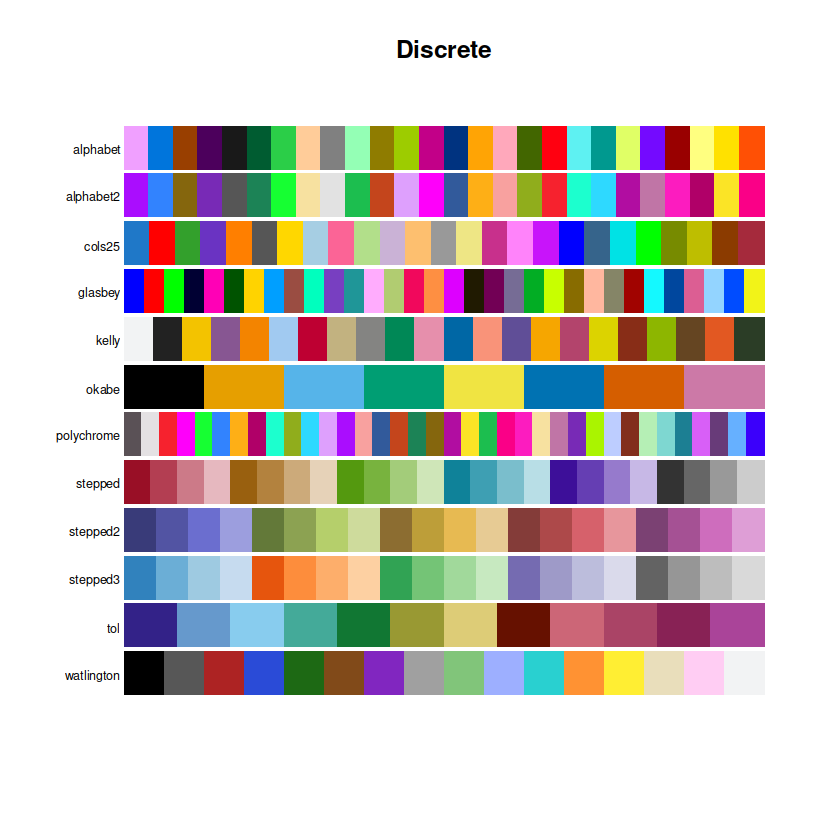

In [40]:
library(pals)
pal.bands(alphabet, alphabet2, cols25, glasbey, kelly, okabe, polychrome, stepped, stepped2, stepped3, tol, watlington,
          main="Discrete", show.names=FALSE)


# # Use pals Alphabet2 palette but swap Iron & ultraviolet & remove names
# # Get the palette
# tissue_colors_palsalphabet2 <- alphabet2(21)

# # Find which positions have those colors
# iron_pos <- which(tissue_colors_palsalphabet2 == "#E2E2E2")
# ultraviolet_pos <- which(tissue_colors_palsalphabet2 == "#B10DA1")

# # Swap them
# tissue_colors_palsalphabet2[iron_pos] <- "#B10DA1"
# tissue_colors_palsalphabet2[ultraviolet_pos] <- "#E2E2E2"

# # Remove names - use as.character() to get just the hex codes
# tissue_colors_palsalphabet2 <- as.character(tissue_colors_palsalphabet2)

# # Now you have just a vector of hex codes with no names
# tissue_colors_palsalphabet2

# # View the result
# scales::show_col(tissue_colors_palsalphabet2)
# #tissue_colors_palsalphabet2


## instead use this manual color scheme from Figure 2!


tissue_colors <- c(
  'Adipose Tissue'             = "#eee8aa",  # pale goldenrod
  'Cancer or Tumor'            = "#8b4513",  # saddle brown
  'Cardiovascular System'      = "#ff7f50",  # coral
  'Cell Line'                  = "#a9a9a9",  # dark gray
  'Digestive System'           = "#6b8e23",  # olive drab
  'Endocrine System'           = "#da70d6",  # orchid
  'Hematopoietic System'       = "#dc143c",  # crimson
  'Liver and Biliary System'   = "#daa520",  # goldenrod
  'Muscular System'            = "#9370db",  # medium purple
  'Nervous System'             = "#008b8b",  # dark cyan
  'Renal System'               = "#4682b4",  # steel blue
  'Reproductive System'        = "#db7093",  # pale violet red
  'Respiratory System'         = "#6495ed",  # cornflower blue
  'Sensory System'             = "#20b2aa",  # light sea green
  'Skeletal Element'           = "#bc8f8f",  # rosy brown
  'Surface Structure'          = "#deb887",  # burlywood
  'Swim Bladder'               = "#66cdaa",  # medium aquamarine
  'Embryo Imprecise'           = "#dc143c",  # not in legend - reusing crimson
  'All anatomical structures'  = "#eee8aa",  # not in legend - reusing pale goldenrod
  'Multi-system'               = "#bdbdbd",  # light gray (Multi-tissue/Undetermined)
  'Undetermined'               = "#e0e0e0"   # lighter gray
)

In [37]:
unique(virus_by_tissue_ordered$tissue_curation_coarse2)

[1] Adipose Tissue            All anatomical structures
 [3] Cancer or Tumor           Cardiovascular System    
 [5] Cell Line                 Digestive System         
 [7] Embryo Imprecise          Endocrine System         
 [9] Hematopoietic System      Liver and Biliary System 
[11] Multi-system              Muscular System          
[13] Nervous System            Renal System             
[15] Reproductive System       Respiratory System       
[17] Sensory System            Skeletal Element         
[19] Surface Structure         Swim Bladder             
[21] Undetermined             
21 Levels: Adipose Tissue Cancer or Tumor Cardiovascular System ... Undetermined

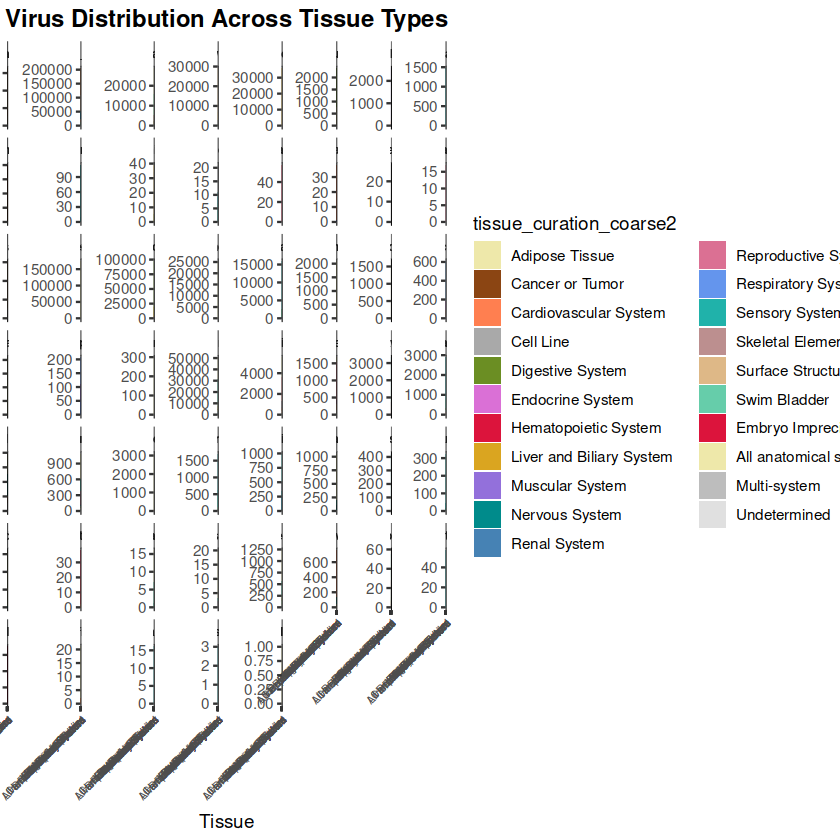

In [41]:
# Apply to your plot

## try 8 panel wide version

# virus_by_tissue_ordered2 <- virus_by_tissue_ordered %>%
#   mutate(virus = str_remove(virus, "^(endogenous_or_nonfish |insufficient_evidence )"))


ggplot(virus_by_tissue_ordered, aes(x = tissue_curation_coarse2, y = total_counts, fill = tissue_curation_coarse2)) +
  geom_col() +
  scale_fill_manual(values = tissue_colors) +
  facet_wrap(~virus, scales = "free_y", ncol = 8,
    labeller = labeller(virus = ~ str_remove(.x, "^(endogenous_or_nonfish |insufficient_evidence )"))
  ) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 6),
    strip.text = element_text(size = 7, face = "bold"),
    strip.background = element_rect(fill = "lightgray"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold")
  ) +
  labs(
    x = "Tissue", 
    y = "Total counts", 
    title = "Virus Distribution Across Tissue Types"
  )



In [42]:
## and save
ggsave("virus_by_tissue_53viruses8panelswide2.pdf", width = 27, height = 11)

In [ ]:
## version of above plot but only with 3 viruses:
## march update - use 5 

# Filter for just the three viruses you want
# virus_3subset <- c("Novel fish-associated jawpox virus", 
#                   "Zebrafish picornavirus 1", 
#                   "Zebrafish picornavirus 2",                    
#                   "Novel fish-associated betainfluenza-like virus", 
#                    "Novel fish-associated picornavirus - China")

## need new names
virus_3subset <- c("Zebrafish jaw poxvirus", 
                  "Zebrafish picornavirus 1", 
                  "Danio blood picornavirus_Zebrafish picornavirus 2",                    
                  "Influenza Z virus", 
                   "Zebrafish jaw picornavirus")


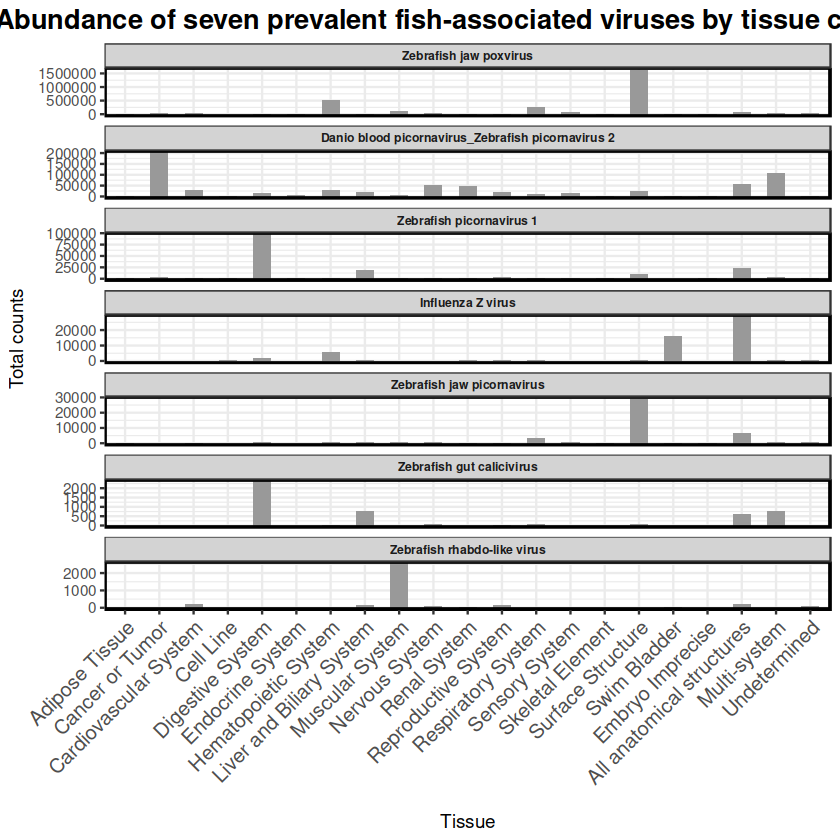

In [43]:
## let's try 8 viruses - 8th is much less common so going with 7


virus_7subset <- c("Zebrafish jaw poxvirus", 
                  "Zebrafish picornavirus 1", 
                  "Danio blood picornavirus_Zebrafish picornavirus 2",                    
                  "Influenza Z virus", 
                  "Zebrafish rhabdo-like virus", 
                  "Zebrafish gut calicivirus", 
#                  "Zebrafish systemic paramyxovirus", 
                   "Zebrafish jaw picornavirus")


## thinbars all gray but sorted by virus counts!!

# Calculate total counts per virus and create ordered factor
virus_order7 <- virus_by_tissue_ordered %>%
  filter(virus %in% virus_7subset) %>%
  group_by(virus) %>%
  summarise(virus_total = sum(total_counts, na.rm = TRUE)) %>%
  arrange(desc(virus_total)) %>%
  pull(virus)


virus_by_tissue_7viruses_thinbars_allgray <- virus_by_tissue_ordered %>%
  filter(virus %in% virus_7subset) %>%
  mutate(virus = factor(virus, levels = virus_order7)) %>%
  ggplot(aes(x = tissue_curation_coarse2, y = total_counts)) +
  geom_col(width = 0.5, fill = "gray60") +  # All gray
  facet_wrap(~virus, scales = "free_y", ncol = 1) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    strip.text = element_text(size = 7, face = "bold"),
    strip.background = element_rect(fill = "lightgray"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold")
  ) +
  labs(
    x = "Tissue", 
    y = "Total counts", 
    title = "Abundance of seven prevalent fish-associated viruses by tissue category"
  )
virus_by_tissue_7viruses_thinbars_allgray



In [44]:
ggsave("virus_by_tissue_7viruses_vertical_allgray2.pdf", virus_by_tissue_7viruses_thinbars_allgray, width = 8.5, height = 13.5)

In [ ]:
## repeat the 53 virus panel figure for tissue type, also year of submission & submission country


In [46]:
## next - devstage
virus_by_devstage <- virus_data %>%
  group_by(devstage_curation_coarse) %>%
  summarise(across(all_of(virus_cols), ~sum(., na.rm = TRUE))) %>%
  pivot_longer(-devstage_curation_coarse, names_to = "virus", values_to = "total_counts") %>%
  filter(total_counts > 0)

virus_by_devstage0 <- virus_by_devstage
virus_by_devstage <- left_join(virus_by_devstage0,viruses_withcategory12)

head(virus_by_devstage)





Joining with `by = join_by(virus)`


devstage_curation_coarse,virus,total_counts,Category
<fct>,<chr>,<dbl>,<chr>
Adult,Zebrafish jaw poxvirus,2316861,Novel
Adult,Danio blood picornavirus_Zebrafish picornavirus 2,273992,Novel
Adult,Influenza Z virus,18465,Novel
Adult,Zebrafish jaw picornavirus,33973,Novel
Adult,Zebrafish hepatic paramyxovirus,35586,Novel
Adult,Zebrafish gut calicivirus,4053,Novel


In [47]:
unique(virus_by_devstage$devstage_curation_coarse)

[1] Adult        Embryo       Juvenile     Larval       Multi-stage 
[6] Undetermined
Levels: Adult Embryo Juvenile Larval Multi-stage Undetermined

In [48]:
# Prepare data for plotting with custom virus_by_tissue order
## for tissue type recapitulate...

# Get all unique devstage categories
all_devstage <- unique(virus_by_devstage$devstage_curation_coarse)
all_devstage <- all_devstage[!is.na(all_devstage)]

end2_categories <- c("Multi-stage", "Undetermined")

# Alphabetical tissues excluding the end ones
alpha_devstage <- sort(setdiff(all_devstage, end2_categories))

# Combine: alphabetical first, then special ones at end
devstage_order <- c(alpha_devstage, intersect(end2_categories, all_devstage))

# virus_by_devstage <- virus_by_devstage %>%
#   mutate(devstage_curation_coarse2 = factor(devstage_curation_coarse, levels = devstage_order))

#virus_by_devstage

## instead manually make the order!

devstage_order2 <- c("Embryo","Larval","Juvenile","Adult","Multi-stage", "Undetermined")


virus_by_devstage <- virus_by_devstage %>%
  mutate(devstage_curation_coarse2 = factor(devstage_curation_coarse, levels = devstage_order2))


In [49]:
virus_order

[1] "Zebrafish jaw poxvirus"                                             
 [2] "Danio blood picornavirus_Zebrafish picornavirus 2"                  
 [3] "Influenza Z virus"                                                  
 [4] "Zebrafish jaw picornavirus"                                         
 [5] "Zebrafish hepatic paramyxovirus"                                    
 [6] "Zebrafish gut calicivirus"                                          
 [7] "Zebrafish rhabdo-like virus"                                        
 [8] "Zebrafish arterivirus"                                              
 [9] "Zebrafish neurinoma calicivirus"                                    
[10] "Zebrafish neural hantavirus"                                        
[11] "Zebrafish systemic paramyxovirus"                                   
[12] "Zebrafish influenza-like virus"                                     
[13] "Zebrafish adomavirus"                                               
[14] "Zebrafish cardiovascular hantavirus"                                
[15] "Zebrafish systemic calicivirus"                                     
[16] "Zebrafish gonadal hantavirus"                                       
[17] "Spring viraemia of carp virus"                                      
[18] "Cyprinid herpesvirus 3"                                             
[19] "Zebrafish picornavirus 1"                                           
[20] "Redspotted grouper nervous necrosis virus"                          
[21] "Rocky Mountain birnavirus"                                          
[22] "Largemouth bass virus"                                              
[23] "Infectious Salmon Anemia Virus"                                     
[24] "Myotis ricketti associated fish calicivirus"                        
[25] "Wenzhou shark flavivirus"                                           
[26] "Grass carp reovirus"                                                
[27] "Singapore grouper virus"                                            
[28] "endogenous_or_nonfish Pimephales minnow adintovirus"                
[29] "endogenous_or_nonfish Chuvivirus"                                   
[30] "endogenous_or_nonfish Sea turtle neural virus 1"                    
[31] "endogenous_or_nonfish Psittacidae aveparvovirus"                    
[32] "endogenous_or_nonfish Adintovirus anguilla10665"                    
[33] "endogenous_or_nonfish African cichlid piscichuvirus"                
[34] "endogenous_or_nonfish Salarius guttatus piscichuvirus"              
[35] "endogenous_or_nonfish Deltainfluenzavirus"                          
[36] "endogenous_or_nonfish Fish-associated parvo-like hybrid virus"      
[37] "endogenous_or_nonfish Fish-associated picorna-like virus 3"         
[38] "endogenous_or_nonfish Psittaciform aveparvovirus"                   
[39] "endogenous_or_nonfish Flumine Astrovirus 3"                         
[40] "endogenous_or_nonfish Luscinia sibilans parvo-like hybrid virus"    
[41] "endogenous_or_nonfish Hardyhead chuvirus"                           
[42] "endogenous_or_nonfish Leatherback sea turtle adomavirus"            
[43] "endogenous_or_nonfish Phoenicopteridae parvo-like hybrid virus"     
[44] "endogenous_or_nonfish Phoenicopterus roseus parvo-like hybrid virus"
[45] "insufficient_evidence Cyprinid herpesvirus 1"                       
[46] "insufficient_evidence Astyanax tetra cavefish adintovirus"          
[47] "insufficient_evidence Larimichthys croaker adintovirus"             
[48] "insufficient_evidence Cutthroat trout virus"                        
[49] "insufficient_evidence Catfish adomavirus"                           
[50] "insufficient_evidence Blueface angelfish adomavirus"                
[51] "insufficient_evidence Blotched snakehead virus"                     
[52] "insufficient_evidence Guangdong catfish astro-like virus"           
[53] "insufficient_evidence Snakehead retrovirus"

In [50]:
# Now apply this ordering to your plot data
virus_by_devstage_ordered <- virus_by_devstage %>%
#  mutate(virus = factor(virus, levels = virus_order2))
  mutate(virus = factor(virus, levels = virus_order))
virus_by_devstage_ordered

devstage_curation_coarse,virus,total_counts,Category,devstage_curation_coarse2
<fct>,<fct>,<dbl>,<chr>,<fct>
Adult,Zebrafish jaw poxvirus,2316861,Novel,Adult
Adult,Danio blood picornavirus_Zebrafish picornavirus 2,273992,Novel,Adult
Adult,Influenza Z virus,18465,Novel,Adult
Adult,Zebrafish jaw picornavirus,33973,Novel,Adult
Adult,Zebrafish hepatic paramyxovirus,35586,Novel,Adult
Adult,Zebrafish gut calicivirus,4053,Novel,Adult
Adult,Zebrafish rhabdo-like virus,561,Novel,Adult
Adult,Zebrafish arterivirus,1461,Novel,Adult
Adult,Zebrafish neurinoma calicivirus,7,Novel,Adult


In [51]:
unique(virus_by_devstage_ordered$devstage_curation_coarse2)

[1] Adult        Embryo       Juvenile     Larval       Multi-stage 
[6] Undetermined
Levels: Embryo Larval Juvenile Adult Multi-stage Undetermined

In [53]:
## new manual color palette - this is full set of devstages
## equivalent to RColorBrewer::brewer.pal(11, "RdYlBu") s
devstage_colorsfull <- c(
  'Zygote'        = "#a50026",  # RdYlBu 1  - dark red
  'Cleavage'      = "#d73027",  # RdYlBu 2  - red
  'Blastula'      = "#f46d43",  # RdYlBu 3  - orange-red
  'Gastrula'      = "#fdae61",  # RdYlBu 4  - orange
  'Segmentation'  = "#fee090",  # RdYlBu 5  - yellow-orange
  'Pharyngula'    = "#ffffbf",  # RdYlBu 6  - light yellow (midpoint)
  'Hatching'      = "#e0f3f8",  # RdYlBu 7  - light cyan
  'Larval'        = "#abd9e9",  # RdYlBu 8  - light blue
  'Juvenile'      = "#74add1",  # RdYlBu 9  - medium blue
  'Adult'         = "#4575b4",  # RdYlBu 10 - blue
  'Multi-stage'   = "#313695",  # RdYlBu 11 - dark blue
  'Undetermined'  = "#808080"   # gray (appended)
)

devstage_colors <- c(
  'Zygote'        = "#a50026",  # RdYlBu 1  - dark red
  'Cleavage'      = "#d73027",  # RdYlBu 2  - red
  'Blastula'      = "#f46d43",  # RdYlBu 3  - orange-red
  'Gastrula'      = "#fdae61",  # RdYlBu 4  - orange
  'Segmentation'  = "#fee090",  # RdYlBu 5  - yellow-orange
  'Pharyngula'    = "#ffffbf",  # RdYlBu 6  - light yellow (midpoint)
  'Hatching'      = "#e0f3f8",  # RdYlBu 7  - light cyan
  'Embryo'        = "#d73027",  # RdYlBu 2  - red    
  'Larval'        = "#abd9e9",  # RdYlBu 8  - light blue
  'Juvenile'      = "#74add1",  # RdYlBu 9  - medium blue
  'Adult'         = "#4575b4",  # RdYlBu 10 - blue
  'Multi-stage'   = "#313695",  # RdYlBu 11 - dark blue
  'Undetermined'  = "#808080"   # gray (appended)
)

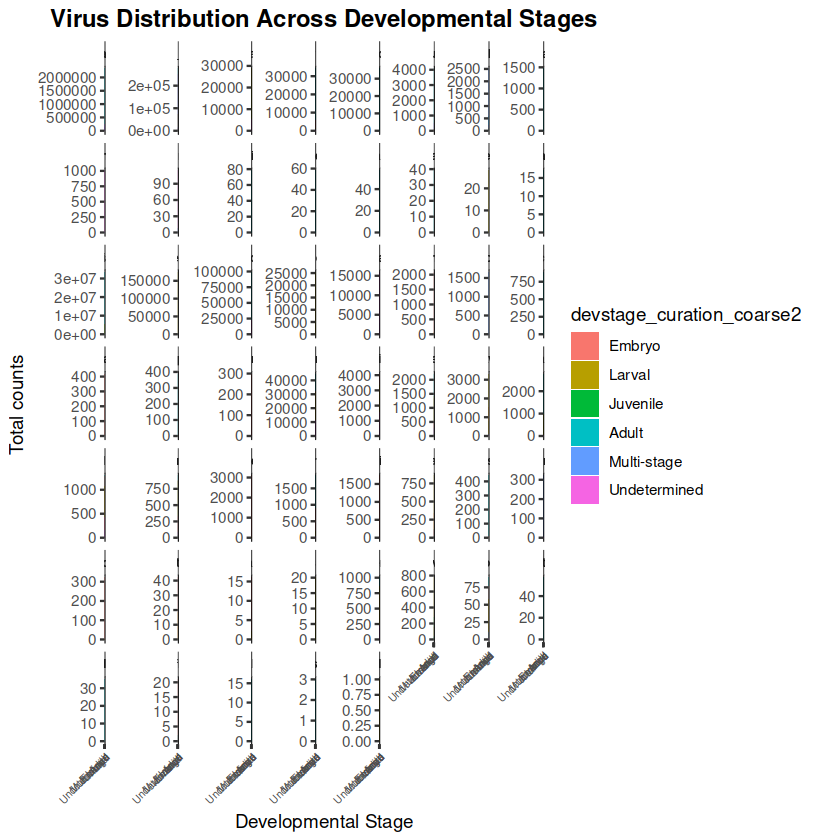

In [55]:
## try 8 panel wide version
# virus_by_devstage_ordered2 <- virus_by_devstage_ordered %>%
#   mutate(virus = str_remove(virus, "^(endogenous_or_nonfish |insufficient_evidence )"))

## ACTUALLY COLORS ARE PRETTY GOOFY WITH ONLY COARSE EMBRYO...GOING BACK TO GGPLOT DEFAULT...

ggplot(virus_by_devstage_ordered, aes(x = devstage_curation_coarse2, y = total_counts, fill = devstage_curation_coarse2)) +
  geom_col() +
#  scale_fill_manual(values = devstage_colors) +
  facet_wrap(~virus, scales = "free_y", ncol = 8,
    labeller = labeller(virus = ~ str_remove(.x, "^(endogenous_or_nonfish |insufficient_evidence )"))
  ) +  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 6),
    strip.text = element_text(size = 7, face = "bold"),
    strip.background = element_rect(fill = "lightgray"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold")
  ) +
  labs(
    x = "Developmental Stage", 
    y = "Total counts", 
    title = "Virus Distribution Across Developmental Stages"
  )



In [56]:
## and save
ggsave("virus_by_devstage_53viruses8panelswide2.pdf", width = 27, height = 11)

[1] "#AA0DFE" "#3283FE" "#85660D" "#782AB6" "#565656" "#1C8356" "#16FF32"
 [8] "#F7E1A0" "#B10DA1" "#1CBE4F" "#C4451C" "#DEA0FD" "#FE00FA" "#325A9B"
[15] "#FEAF16" "#F8A19F" "#90AD1C" "#F6222E" "#1CFFCE" "#2ED9FF" "#E2E2E2"

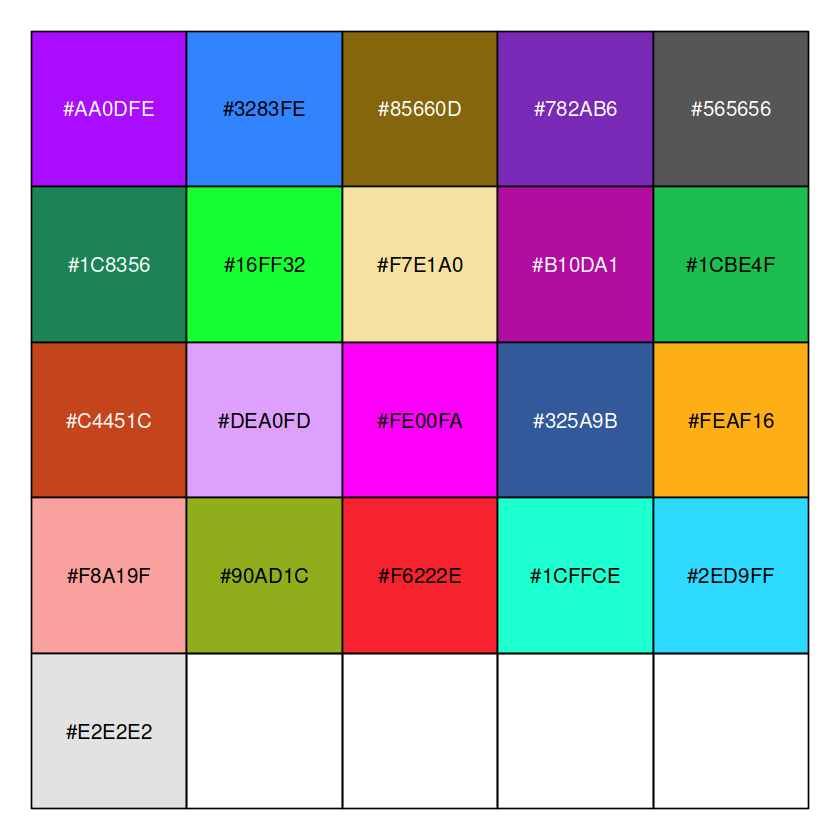

In [57]:
## need to revisit old color palettes...


# Use pals Alphabet2 palette but swap Iron & ultraviolet & remove names
# Get the palette
tissue_colors_palsalphabet2 <- alphabet2(21)

# Find which positions have those colors
iron_pos <- which(tissue_colors_palsalphabet2 == "#E2E2E2")
ultraviolet_pos <- which(tissue_colors_palsalphabet2 == "#B10DA1")

# Swap them
tissue_colors_palsalphabet2[iron_pos] <- "#B10DA1"
tissue_colors_palsalphabet2[ultraviolet_pos] <- "#E2E2E2"

# Remove names - use as.character() to get just the hex codes
tissue_colors_palsalphabet2 <- as.character(tissue_colors_palsalphabet2)

# Now you have just a vector of hex codes with no names
tissue_colors_palsalphabet2

# View the result
scales::show_col(tissue_colors_palsalphabet2)
#tissue_colors_palsalphabet2


In [58]:
### now by year


virus_by_year0 <- virus_datamore %>%
  group_by(earliest_date) %>%
  summarise(across(all_of(virus_cols), ~sum(., na.rm = TRUE))) %>%
  pivot_longer(-earliest_date, names_to = "virus", values_to = "total_counts") %>%
  filter(total_counts > 0)

virus_by_year01 <- virus_by_year0
virus_by_year0 <- left_join(virus_by_year01,viruses_withcategory12)

head(virus_by_year0)

### create year column

library(lubridate)

virus_by_year <- virus_by_year0 %>%
  mutate(earliest_year = year(earliest_date))

# Check the result
virus_by_year %>%
  select(earliest_date, earliest_year) %>%
  head()

unique(virus_by_year$earliest_year)




Joining with `by = join_by(virus)`


earliest_date,virus,total_counts,Category
<fct>,<chr>,<dbl>,<chr>
2010-02-26,Zebrafish jaw poxvirus,173,Novel
2010-03-23,endogenous_or_nonfish Pimephales minnow adintovirus,76,Endogenous or not fish-associated
2010-03-23,endogenous_or_nonfish Chuvivirus,2,Endogenous or not fish-associated
2010-03-23,endogenous_or_nonfish Sea turtle neural virus 1,1,Endogenous or not fish-associated
2010-03-23,endogenous_or_nonfish African cichlid piscichuvirus,1,Endogenous or not fish-associated
2010-07-08,Zebrafish jaw poxvirus,1,Novel


earliest_date,earliest_year
<fct>,<int>
2010-02-26,2010
2010-03-23,2010
2010-03-23,2010
2010-03-23,2010
2010-03-23,2010
2010-07-08,2010


[1] 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024
[16] 2025

In [59]:
virus_by_year <- virus_by_year %>%
mutate(earliest_year = factor(earliest_year, levels = sort(unique(earliest_year))))

unique(virus_by_year$earliest_year)


[1] 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024
[16] 2025
16 Levels: 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 ... 2025

earliest_date,virus,total_counts,Category,earliest_year
<fct>,<fct>,<dbl>,<chr>,<fct>
2010-02-26,Zebrafish jaw poxvirus,173,Novel,2010
2010-03-23,endogenous_or_nonfish Pimephales minnow adintovirus,76,Endogenous or not fish-associated,2010
2010-03-23,endogenous_or_nonfish Chuvivirus,2,Endogenous or not fish-associated,2010
2010-03-23,endogenous_or_nonfish Sea turtle neural virus 1,1,Endogenous or not fish-associated,2010
2010-03-23,endogenous_or_nonfish African cichlid piscichuvirus,1,Endogenous or not fish-associated,2010
2010-07-08,Zebrafish jaw poxvirus,1,Novel,2010


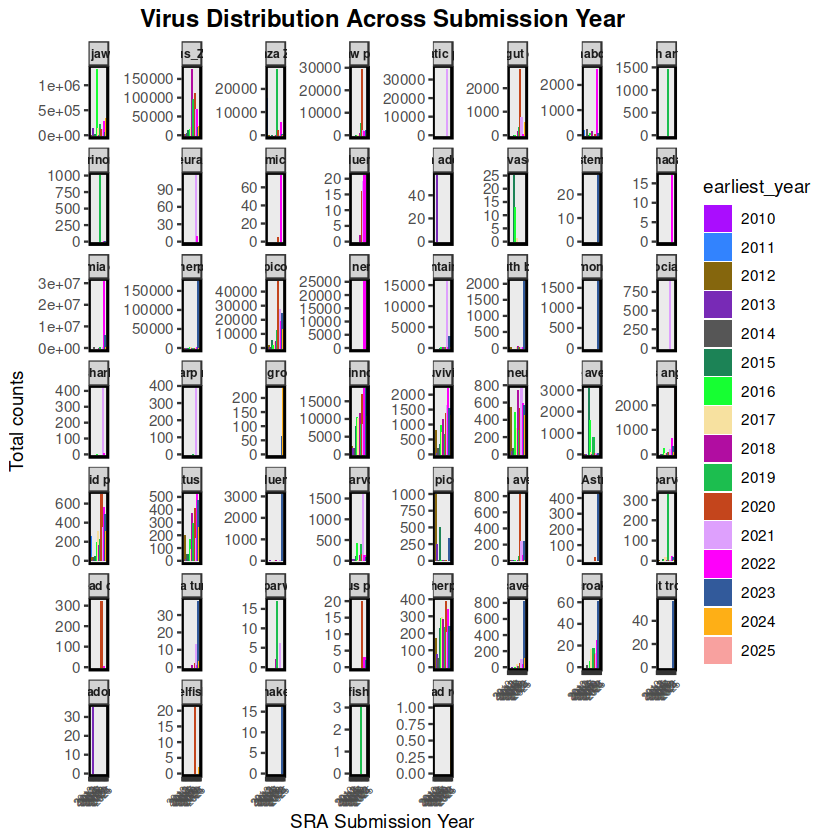

In [60]:
# Now apply this ordering to your plot data
virus_by_year_ordered <- virus_by_year %>%
#  mutate(virus = factor(virus, levels = virus_order2))
  mutate(virus = factor(virus, levels = virus_order))
head(virus_by_year_ordered)

## try 8 panel wide version
ggplot(virus_by_year_ordered, aes(x = earliest_year, y = total_counts, fill = earliest_year)) +
  geom_col() +
  scale_fill_manual(values = tissue_colors_palsalphabet2) +
  facet_wrap(~virus, scales = "free_y", ncol = 8,
    labeller = labeller(virus = ~ str_remove(.x, "^(endogenous_or_nonfish |insufficient_evidence )"))
  ) +  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 6),
    strip.text = element_text(size = 7, face = "bold"),
    strip.background = element_rect(fill = "lightgray"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold")
  ) +
  labs(
    x = "SRA Submission Year", 
    y = "Total counts", 
    title = "Virus Distribution Across Submission Year"
  )


In [61]:
## and save
ggsave("virus_by_year_53viruses8panelswide2.pdf", width = 27, height = 11)

In [62]:
## now by submission country

virus_by_country0 <- virus_datamore %>%
  group_by(submission.bioprojectsource.country) %>%
  summarise(across(all_of(virus_cols), ~sum(., na.rm = TRUE))) %>%
  pivot_longer(-submission.bioprojectsource.country, names_to = "virus", values_to = "total_counts") %>%
  filter(total_counts > 0)

virus_by_country01 <- virus_by_country0
virus_by_country0 <- left_join(virus_by_country01,viruses_withcategory12)

head(virus_by_country0)

### just top 12 countries
## need to just sum all of the virus counts to get a country count
virus_by_country02 <- virus_by_country0 %>%
  group_by(submission.bioprojectsource.country) %>%
  mutate(countrycount = sum(total_counts)) %>%
  ungroup()


virus_by_country02 <- virus_by_country02 %>% arrange(desc(countrycount))

virus_by_country02 %>% group_by(submission.bioprojectsource.country) %>% select(submission.bioprojectsource.country,countrycount) %>% unique() %>% ungroup()


Joining with `by = join_by(virus)`


submission.bioprojectsource.country,virus,total_counts,Category
<fct>,<chr>,<dbl>,<chr>
Australia,Zebrafish jaw poxvirus,64,Novel
Australia,Danio blood picornavirus_Zebrafish picornavirus 2,11059,Novel
Australia,Cyprinid herpesvirus 3,1,Known
Australia,Zebrafish picornavirus 1,3308,Known
Australia,endogenous_or_nonfish Pimephales minnow adintovirus,8842,Endogenous or not fish-associated
Australia,endogenous_or_nonfish Chuvivirus,87,Endogenous or not fish-associated


submission.bioprojectsource.country,countrycount
<fct>,<dbl>
China,39501095
United States,2166693
Germany,291862
Spain,243858
United Kingdom,198430
Belgium,179710
Canada,103656
Norway,46136
France,31132


In [63]:
## checks!
virus_by_country0 %>%
  group_by(submission.bioprojectsource.country) %>%
  summarise(countrycount = sum(total_counts)) %>% head()

sum(virus_by_country0$total_counts)

# Sum of countrycount (deduplicated to one per country first)
virus_by_country02 %>%
  distinct(submission.bioprojectsource.country, countrycount) %>%
  summarise(total = sum(countrycount))

submission.bioprojectsource.country,countrycount
<fct>,<dbl>
Australia,23593
Austria,2990
Belgium,179710
Brazil,229
Canada,103656
Chile,113


[1] 42926972

total
<dbl>
42926972


In [64]:
unique(virus_by_country02$submission.bioprojectsource.country)

[1] China                United States        Germany             
 [4] Spain                United Kingdom       Belgium             
 [7] Canada               Norway               France              
[10] Netherlands          Turkey               Portugal            
[13] Australia            Japan                Singapore           
[16] Unknown              India                Israel              
[19] Switzerland          Austria              Sweden              
[22] Denmark              Taiwan               Poland              
[25] South Korea          Ireland              New Zealand         
[28] Italy                Russia               Finland             
[31] Mexico               United Arab Emirates Brazil              
[34] Chile                Serbia               Czech Republic      
[37] Hungary              Indonesia            Malaysia            
[40] Estonia              Greece               Qatar               
43 Levels: Australia Austria Belgium Brazil Canada Chile ... Unknown

In [65]:
## top 12

top12_countries <- virus_by_country02 %>%
  distinct(submission.bioprojectsource.country, countrycount) %>%
  arrange(desc(countrycount)) %>%
  head(12) %>%
  pull(submission.bioprojectsource.country)

top12_countries

[1] China          United States  Germany        Spain          United Kingdom
 [6] Belgium        Canada         Norway         France         Netherlands   
[11] Turkey         Portugal      
43 Levels: Australia Austria Belgium Brazil Canada Chile ... Unknown

In [66]:
virus_by_country_top12 <- virus_by_country02 %>%
  filter(submission.bioprojectsource.country %in% top12_countries)

In [67]:
#country_order <- unique(top12_countries)


country_order <- virus_by_country02 %>%
  distinct(submission.bioprojectsource.country, countrycount) %>%
  arrange(desc(countrycount)) %>%
  head(12) %>%
  pull(submission.bioprojectsource.country) %>% 
  as.character()

c2_categories <- c("Others")

# Combine: alphabetical first, then special ones at end
country_order2 <- c(country_order, c2_categories)

country_order2

# virus_by_country_top12 <- virus_by_country_top12 %>%
#   mutate(submission.bioprojectsource.country2 = factor(submission.bioprojectsource.country, levels = country_order))


[1] "China"          "United States"  "Germany"        "Spain"         
 [5] "United Kingdom" "Belgium"        "Canada"         "Norway"        
 [9] "France"         "Netherlands"    "Turkey"         "Portugal"      
[13] "Others"

In [68]:
country_order

[1] "China"          "United States"  "Germany"        "Spain"         
 [5] "United Kingdom" "Belgium"        "Canada"         "Norway"        
 [9] "France"         "Netherlands"    "Turkey"         "Portugal"

In [69]:
## 13th category - all others into "Others"
virus_by_country_final <- virus_by_country02 %>%
  mutate(
    country_display = if_else(
      submission.bioprojectsource.country %in% top12_countries,
      submission.bioprojectsource.country,
      "Others"
    )
  ) %>%
  group_by(country_display, virus) %>%
  summarise(total_counts = sum(total_counts), .groups = "drop") %>%
  group_by(country_display) %>%
  mutate(countrycount = sum(total_counts)) %>%
  ungroup()


virus_by_country_final <- virus_by_country_final %>%
  mutate(submission.bioprojectsource.country2 = factor(country_display, levels = country_order2))


In [70]:
head(virus_by_country_final)

country_display,virus,total_counts,countrycount,submission.bioprojectsource.country2
<chr>,<chr>,<dbl>,<dbl>,<fct>
Belgium,Cyprinid herpesvirus 3,173426,179710,Belgium
Belgium,Danio blood picornavirus_Zebrafish picornavirus 2,1123,179710,Belgium
Belgium,Largemouth bass virus,3,179710,Belgium
Belgium,Zebrafish jaw picornavirus,2,179710,Belgium
Belgium,Zebrafish jaw poxvirus,2349,179710,Belgium
Belgium,Zebrafish picornavirus 1,1043,179710,Belgium


In [71]:


# Now apply this ordering to your plot data
virus_by_country_ordered <- virus_by_country_final %>%
#  mutate(virus = factor(virus, levels = virus_order2))
  mutate(virus = factor(virus, levels = virus_order))
head(virus_by_country_ordered)


country_display,virus,total_counts,countrycount,submission.bioprojectsource.country2
<chr>,<fct>,<dbl>,<dbl>,<fct>
Belgium,Cyprinid herpesvirus 3,173426,179710,Belgium
Belgium,Danio blood picornavirus_Zebrafish picornavirus 2,1123,179710,Belgium
Belgium,Largemouth bass virus,3,179710,Belgium
Belgium,Zebrafish jaw picornavirus,2,179710,Belgium
Belgium,Zebrafish jaw poxvirus,2349,179710,Belgium
Belgium,Zebrafish picornavirus 1,1043,179710,Belgium


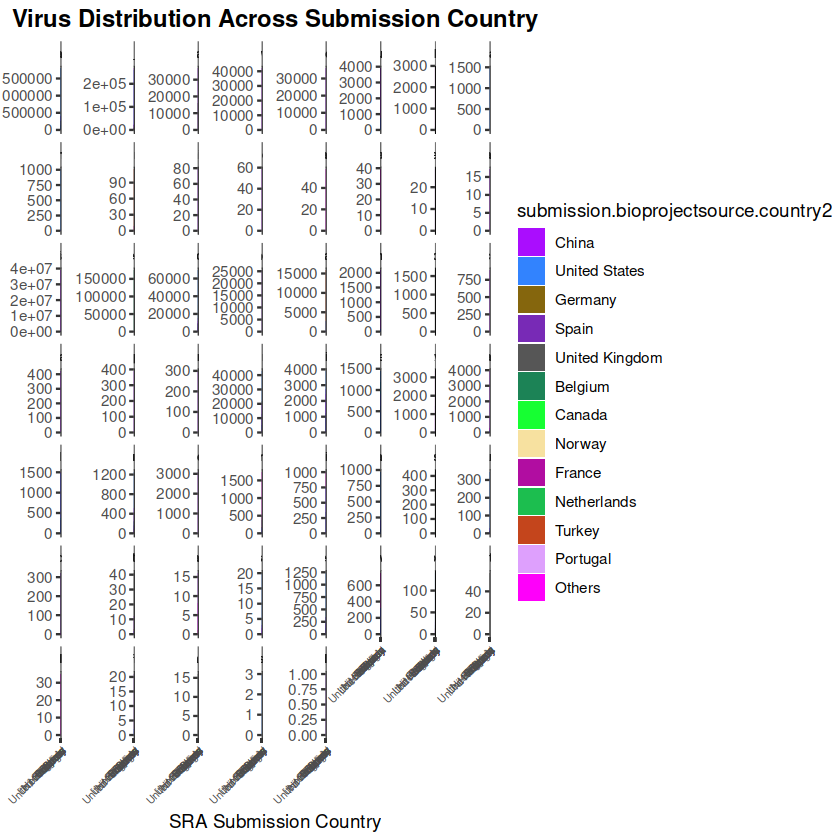

In [72]:


## try 8 panel wide version
ggplot(virus_by_country_ordered, aes(x = submission.bioprojectsource.country2, y = total_counts, fill = submission.bioprojectsource.country2)) +
  geom_col() +
  scale_fill_manual(values = tissue_colors_palsalphabet2) +
  facet_wrap(~virus, scales = "free_y", ncol = 8,
    labeller = labeller(virus = ~ str_remove(.x, "^(endogenous_or_nonfish |insufficient_evidence )"))
  ) +  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 6),
    strip.text = element_text(size = 7, face = "bold"),
    strip.background = element_rect(fill = "lightgray"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold")
  ) +
  labs(
    x = "SRA Submission Country", 
    y = "Total counts", 
    title = "Virus Distribution Across Submission Country"
  )


In [73]:
## and save
ggsave("virus_by_country_53viruses8panelswide2.pdf", width = 27, height = 11)